In [ ]:
import pandas as pd

df = pd.read_csv("../data/processed/classified_returns.csv")

df.head()

,Order_ID,Product_ID,User_ID,Order_Date,Product_Category,Product_Price,Order_Quantity,Discount_Applied,Shipping_Method,Payment_Method,...,Order_Value,Return_Cost,Profit_Loss,CO2_Emissions,Packaging_Waste,CO2_Saved,Waste_Avoided,category,confidence,key_signal
0,ORD00000,PROD0169,USER0195,2022-01-14,Clothing,1720.71,2,30.46,Next-Day,Wallet,...,2393.163468,0,2393.163468,2.0,0.4,2.0,0.4,ERROR,0,Expecting value: line 1 column 1 (char 0)
1,ORD00001,PROD0318,USER1469,2022-01-03,Toys,744.06,5,29.62,Next-Day,Wallet,...,2618.347140,200,2418.347140,2.0,1.0,0.0,0.0,ERROR,0,Expecting value: line 1 column 1 (char 0)
2,ORD00002,PROD0427,USER1812,2025-03-16,Clothing,983.68,5,47.80,Express,Wallet,...,2567.404800,0,2567.404800,1.5,1.0,1.5,1.0,ERROR,0,Expecting value: line 1 column 1 (char 0)
3,ORD00003,PROD0323,USER1274,2024-11-06,Books,1855.65,2,2.90,Express,COD,...,3603.672300,0,3603.672300,1.5,0.4,1.5,0.4,ERROR,0,Expecting value: line 1 column 1 (char 0)
4,ORD00004,PROD0325,USER0551,2023-06-07,Home Appliances,1770.97,5,44.42,Express,COD,...,4921.525630,200,4721.525630,1.5,1.0,0.0,0.0,ERROR,0,Expecting value: line 1 column 1 (char 0)


In [ ]:
df.shape
df.columns

Index(['Order_ID', 'Product_ID', 'User_ID', 'Order_Date', 'Product_Category',
       'Product_Price', 'Order_Quantity', 'Discount_Applied',
       'Shipping_Method', 'Payment_Method', 'User_Age', 'User_Gender',
       'User_Location', 'Return_Status', 'Return_Reason', 'Days_to_Return',
       'Order_Value', 'Return_Cost', 'Profit_Loss', 'CO2_Emissions',
       'Packaging_Waste', 'CO2_Saved', 'Waste_Avoided', 'category',
       'confidence', 'key_signal'],
      dtype='object')

In [ ]:
df['Return_Status'].value_counts()

Return_Status
Not Returned    3550
Returned        1450
Name: count, dtype: int64

In [ ]:
df['target'] = df['Return_Status'].apply(lambda x: 1 if x == 'Returned' else 0)

In [ ]:
df = df.drop(columns=[
    'Days_to_Return',
    'Return_Cost',
    'Profit_Loss'
])

In [ ]:
features = [
    'Product_Category',
    'Product_Price',
    'Order_Quantity',
    'Discount_Applied',
    'Shipping_Method',
    'Payment_Method',
    'User_Age',
    'User_Gender',
    'User_Location',
    'Order_Value',
    'category'
]

df = df[features + ['target']]

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['target'])
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from xgboost import XGBClassifier

scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

# Lower threshold from 0.5 → 0.3
y_pred = (y_prob > 0.3).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.43      0.55       698
           1       0.34      0.69      0.46       302

    accuracy                           0.51      1000
   macro avg       0.55      0.56      0.51      1000
weighted avg       0.64      0.51      0.52      1000



In [ ]:
!pip install shap


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import shap
shap.initjs()

In [ ]:
explainer = shap.TreeExplainer(model)

In [ ]:
shap_values = explainer.shap_values(X_test)

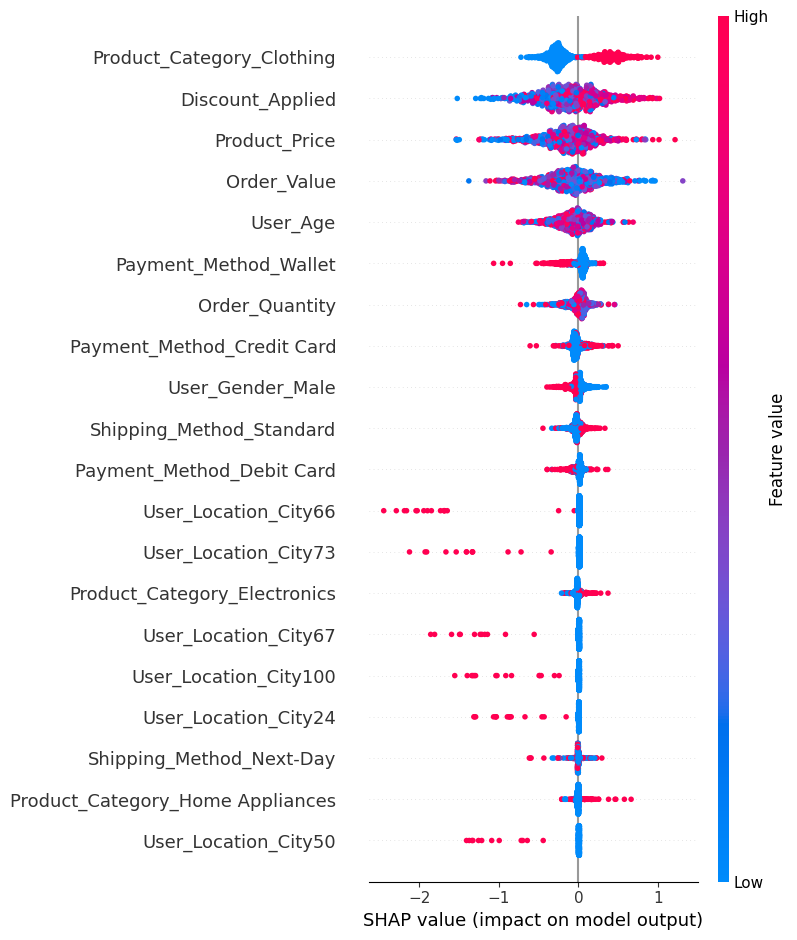

In [ ]:
shap.summary_plot(shap_values, X_test)

In [ ]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)